In [ ]:
import re
import json
import math
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List
from collections import OrderedDict
from tqdm.auto import tqdm
import os
from dotenv import load_dotenv
from tqdm import tqdm
from huggingface_hub import InferenceClient
from pinecone import Pinecone, ServerlessSpec
import os



load_dotenv()

hf_token = os.getenv("hf_token")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

d:\CIC-IDS-17 notebook\llm-ids-shield -copy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
CANONICAL_FEATURES = [
    "Flow_Duration",
    "Dst_Port",
    "Flow_IAT_Min",
    "Flow_IAT_Max",
    "Flow_Pkts/s",
    "Flow_Byts/s",
    "Fwd_Pkts/s",
    "Bwd_Pkts/s",
    "Pkt_Len_Max",
    "Pkt_Len_Std",
    "Fwd_Pkt_Len_Max",
    "Bwd_Pkt_Len_Mean",
    "TotLen_Fwd_Pkts",
    "TotLen_Bwd_Pkts",
    "Init_Bwd_Win_Byts",
    "Bwd_Header_Len",
]

In [13]:
FEATURE_GROUPS = OrderedDict({
    "Connection characteristics": [
        "Flow_Duration",
        "Dst_Port",
    ],
    "Traffic timing": [
        "Flow_IAT_Min",
        "Flow_IAT_Max",
    ],
    "Traffic activity": [
        "Flow_Pkts/s",
        "Fwd_Pkts/s",
        "Bwd_Pkts/s",
    ],
    "Traffic volume": [
        "Flow_Byts/s",
        "TotLen_Fwd_Pkts",
        "TotLen_Bwd_Pkts",
    ],
    "Packet characteristics": [
        "Pkt_Len_Max",
        "Pkt_Len_Std",
        "Fwd_Pkt_Len_Max",
        "Bwd_Pkt_Len_Mean",
    ],
    "Protocol behavior": [
        "Init_Bwd_Win_Byts",
        "Bwd_Header_Len",
    ]
})

### Best Model: XGBOOST

In [ ]:
df = pd.read_csv("results/xgb_predictions.csv")

print(df.shape)
print(df.columns)
df.head(10)

(625783, 30)
Index(['Flow_Duration', 'Dst_Port', 'Flow_IAT_Min', 'Flow_IAT_Mean',
       'Flow_IAT_Max', 'Flow_Pkts/s', 'Flow_Byts/s', 'Pkt_Len_Max',
       'Pkt_Len_Mean', 'Pkt_Size_Avg', 'Pkt_Len_Min', 'Pkt_Len_Std',
       'Idle_Min', 'Idle_Mean', 'Idle_Max', 'Fwd_Pkts/s', 'Bwd_Pkts/s',
       'Init_Bwd_Win_Byts', 'ACK_Flag_Cnt', 'SYN_Flag_Cnt', 'Bwd_Header_Len',
       'Fwd_Pkt_Len_Max', 'Fwd_Pkt_Len_Min', 'Bwd_Pkt_Len_Max',
       'Bwd_Pkt_Len_Mean', 'y_true', 'y_pred', 'confidence', 'fold', 'model'],
      dtype='str')


,Flow_Duration,Dst_Port,Flow_IAT_Min,Flow_IAT_Mean,Flow_IAT_Max,Flow_Pkts/s,Flow_Byts/s,Pkt_Len_Max,Pkt_Len_Mean,Pkt_Size_Avg,Pkt_Len_Min,Pkt_Len_Std,Idle_Min,Idle_Mean,Idle_Max,Fwd_Pkts/s,Bwd_Pkts/s,Init_Bwd_Win_Byts,ACK_Flag_Cnt,SYN_Flag_Cnt,Bwd_Header_Len,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,Bwd_Pkt_Len_Max,Bwd_Pkt_Len_Mean,y_true,y_pred,confidence,fold,model
0,5310,554,1056.0,2655.000000,4254.0,564.971751,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,1056.0,2655.000000,4254.0,188.323917,376.647834,14600,0,1,44,0.0,0.0,0.0,0.000000,0,0,0.999963,1,XGBoost
1,141,9020,70.0,70.500000,71.0,21276.595745,1.990071e+07,1388.0,1048.500000,1398.000000,30.0,679.000000,70.0,70.500000,71.0,0.000000,21276.595745,1869,1,0,96,0.0,0.0,1388.0,935.333333,8,4,0.422501,1,XGBoost
2,157,443,74.0,78.500000,83.0,19108.280255,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,74.0,78.500000,83.0,12738.853503,6369.426752,5840,1,0,32,0.0,0.0,0.0,0.000000,4,4,0.525738,1,XGBoost
3,6799,554,6799.0,6799.000000,6799.0,294.160906,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,6799.0,6799.000000,6799.0,0.000000,294.160906,14600,0,1,44,0.0,0.0,0.0,0.000000,0,0,0.999963,1,XGBoost
4,165,43238,165.0,165.000000,165.0,12121.212121,1.746667e+07,1441.0,1441.000000,2161.500000,1441.0,0.000000,165.0,165.000000,165.0,6060.606061,6060.606061,252,1,0,32,1441.0,1441.0,1441.0,1441.000000,5,2,0.333489,1,XGBoost
5,40,8899,1.0,4.000000,7.0,275000.000000,8.800000e+06,32.0,32.000000,34.909091,32.0,0.000000,3.0,4.333333,7.0,250000.000000,25000.000000,-1,0,0,8,32.0,32.0,32.0,32.000000,5,5,0.999961,1,XGBoost
6,60431,44144,121.0,5493.727273,43394.0,198.573580,1.121444e+05,1388.0,605.692308,656.166667,0.0,589.742371,1394.0,9708.333333,43394.0,82.738992,115.834588,32678,1,0,224,1388.0,1041.0,1097.0,156.714286,0,0,0.999756,1,XGBoost
7,120,49784,120.0,120.000000,120.0,16666.666667,1.181667e+07,1388.0,935.333333,1403.000000,30.0,784.041666,120.0,120.000000,120.0,8333.333333,8333.333333,1869,1,0,32,30.0,30.0,1388.0,1388.000000,6,6,0.991469,1,XGBoost
8,199,10101,199.0,199.000000,199.0,10050.251256,7.396985e+06,1430.0,967.333333,1451.000000,42.0,801.362174,199.0,199.000000,199.0,5025.125628,5025.125628,-1,0,0,8,42.0,42.0,1430.0,1430.000000,2,5,0.368035,1,XGBoost
9,124,9020,124.0,124.000000,124.0,16129.032258,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,124.0,124.000000,124.0,8064.516129,8064.516129,32679,1,0,32,0.0,0.0,0.0,0.000000,7,8,0.431448,1,XGBoost


In [16]:
CANONICAL_FEATURES = [
    "Flow_Duration",
    "Dst_Port",
    "Flow_IAT_Min",
    "Flow_IAT_Max",
    "Flow_Pkts/s",
    "Flow_Byts/s",
    "Fwd_Pkts/s",
    "Bwd_Pkts/s",
    "Pkt_Len_Max",
    "Pkt_Len_Std",
    "Fwd_Pkt_Len_Max",
    "Bwd_Pkt_Len_Mean",
    "Init_Bwd_Win_Byts",
    "Bwd_Header_Len",
]

META_COLUMNS = ["y_true", "y_pred", "confidence", "fold", "model"]

In [17]:
available_features = [c for c in CANONICAL_FEATURES if c in df.columns]
missing_features = [c for c in CANONICAL_FEATURES if c not in df.columns]

print("Available canonical features:", available_features)
print("Missing canonical features:", missing_features)

Available canonical features: ['Flow_Duration', 'Dst_Port', 'Flow_IAT_Min', 'Flow_IAT_Max', 'Flow_Pkts/s', 'Flow_Byts/s', 'Fwd_Pkts/s', 'Bwd_Pkts/s', 'Pkt_Len_Max', 'Pkt_Len_Std', 'Fwd_Pkt_Len_Max', 'Bwd_Pkt_Len_Mean', 'Init_Bwd_Win_Byts', 'Bwd_Header_Len']
Missing canonical features: []


In [18]:
high_conf = df[
    (df["y_true"] == df["y_pred"]) &
    (df["confidence"] >= 0.90)
].copy()

misclassified = df[
    df["y_true"] != df["y_pred"]
].copy()

low_conf = df[
    (df["y_true"] == df["y_pred"]) &
    (df["confidence"] <= 0.70)
].copy()

print("High confidence:", len(high_conf))
print("Misclassified:", len(misclassified))
print("Low confidence:", len(low_conf))

High confidence: 286140
Misclassified: 205502
Low confidence: 115668


In [ ]:

np.random.seed(42)

# add class labels
high_conf["sample_type"] = "high_confidence"
misclassified["sample_type"] = "misclassified"
low_conf["sample_type"] = "low_confidence"

# sample
high_conf_sample = high_conf.sample(n=150, random_state=42)
misclassified_sample = misclassified.sample(n=100, random_state=42)
low_conf_sample = low_conf.sample(n=100, random_state=42)

# merge
embed_df = pd.concat(
    [high_conf_sample, misclassified_sample, low_conf_sample],
    ignore_index=True
)

print(embed_df["sample_type"].value_counts())

sample_type
high_confidence    150
misclassified      100
low_confidence     100
Name: count, dtype: int64


In [20]:
keep_cols = CANONICAL_FEATURES + META_COLUMNS + ["sample_type"]

embed_df = embed_df[keep_cols].copy()

print(embed_df.shape)
embed_df.head()

(350, 20)


,Flow_Duration,Dst_Port,Flow_IAT_Min,Flow_IAT_Max,Flow_Pkts/s,Flow_Byts/s,Fwd_Pkts/s,Bwd_Pkts/s,Pkt_Len_Max,Pkt_Len_Std,Fwd_Pkt_Len_Max,Bwd_Pkt_Len_Mean,Init_Bwd_Win_Byts,Bwd_Header_Len,y_true,y_pred,confidence,fold,model,sample_type
0,280,49784,75.0,205.0,10714.285714,1.487143e+07,7142.857143,3571.428571,1388.0,0.0,1388.0,1388.0,1869,32,6,6,0.999782,3,XGBoost,high_confidence
1,2356,554,2356.0,2356.0,848.896435,0.000000e+00,0.000000,848.896435,0.0,0.0,0.0,0.0,14600,44,0,0,0.999963,2,XGBoost,high_confidence
2,131,57894,131.0,131.0,15267.175573,2.061069e+07,7633.587786,7633.587786,1350.0,0.0,1350.0,1350.0,-1,8,7,7,0.926632,3,XGBoost,high_confidence
3,2534,554,2534.0,2534.0,789.265983,0.000000e+00,0.000000,789.265983,0.0,0.0,0.0,0.0,14600,44,0,0,0.999963,2,XGBoost,high_confidence
4,80,51875,80.0,80.0,25000.000000,3.620000e+07,12500.000000,12500.000000,1448.0,0.0,1448.0,1448.0,252,32,4,4,0.999646,3,XGBoost,high_confidence


In [ ]:

for col in CANONICAL_FEATURES:
    embed_df[col] = pd.to_numeric(embed_df[col], errors="coerce")

embed_df[CANONICAL_FEATURES] = embed_df[CANONICAL_FEATURES].replace([np.inf, -np.inf], np.nan)
embed_df[CANONICAL_FEATURES] = embed_df[CANONICAL_FEATURES].fillna(0)

embed_df.describe()

,Flow_Duration,Dst_Port,Flow_IAT_Min,Flow_IAT_Max,Flow_Pkts/s,Flow_Byts/s,Fwd_Pkts/s,Bwd_Pkts/s,Pkt_Len_Max,Pkt_Len_Std,Fwd_Pkt_Len_Max,Bwd_Pkt_Len_Mean,Init_Bwd_Win_Byts,Bwd_Header_Len,y_true,y_pred,confidence,fold
count,350.000000,350.000000,350.000000,350.000000,3.500000e+02,3.500000e+02,3.500000e+02,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,639.765714,15044.908571,440.808571,554.602857,6.712821e+04,1.244229e+07,4.309180e+04,24036.402727,716.654286,104.033647,372.368571,662.653952,6622.348571,35.782857,4.028571,4.194286,0.663572,2.005714
std,2583.805915,16868.592051,1424.690912,2030.397803,1.718823e+05,1.227466e+07,1.338902e+05,52643.071440,700.518742,243.070893,609.987983,676.573502,13119.162945,27.928659,2.195146,2.223081,0.301806,0.779370
min,2.000000,0.000000,0.000000,2.000000,1.267829e+02,0.000000e+00,0.000000e+00,125.862156,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.256312,1.000000
25%,76.000000,8011.000000,72.000000,74.000000,1.230773e+04,0.000000e+00,0.000000e+00,5298.041202,0.000000,0.000000,0.000000,0.000000,-1.000000,8.000000,3.000000,3.000000,0.356502,1.000000
50%,124.000000,9020.000000,77.500000,114.000000,1.754386e+04,1.134302e+07,7.604673e+03,12121.657361,376.500000,0.000000,9.000000,159.500000,252.000000,32.000000,4.000000,4.000000,0.543440,2.000000
75%,224.750000,10101.000000,123.000000,150.000000,2.631579e+04,2.052581e+07,1.337798e+04,19704.592363,1430.000000,0.000000,940.000000,1430.000000,1869.000000,60.000000,5.000000,5.000000,0.999913,3.000000
max,39726.000000,60822.000000,15775.000000,26832.000000,1.250000e+06,4.022222e+07,1.153846e+06,500000.000000,1460.000000,784.041666,1460.000000,1460.000000,65535.000000,160.000000,8.000000,8.000000,0.999969,3.000000


In [22]:
def percentile_bin(series):

    q = series.quantile([0.2,0.4,0.6,0.8]).values

    def label(v):
        if v == 0:
            return "zero"
        elif v <= q[0]:
            return "very_low"
        elif v <= q[1]:
            return "low"
        elif v <= q[2]:
            return "medium"
        elif v <= q[3]:
            return "high"
        else:
            return "very_high"

    return series.apply(label)

In [23]:
for col in CANONICAL_FEATURES:
    embed_df[f"{col}_level"] = percentile_bin(embed_df[col])

level_cols = [c + "_level" for c in CANONICAL_FEATURES]

embed_df[level_cols].head()

,Flow_Duration_level,Dst_Port_level,Flow_IAT_Min_level,Flow_IAT_Max_level,Flow_Pkts/s_level,Flow_Byts/s_level,Fwd_Pkts/s_level,Bwd_Pkts/s_level,Pkt_Len_Max_level,Pkt_Len_Std_level,Fwd_Pkt_Len_Max_level,Bwd_Pkt_Len_Mean_level,Init_Bwd_Win_Byts_level,Bwd_Header_Len_level
0,very_high,very_high,medium,very_high,very_low,high,medium,very_low,medium,zero,high,medium,medium,low
1,very_high,very_low,very_high,very_high,very_low,zero,zero,very_low,zero,zero,zero,zero,high,high
2,medium,very_high,high,high,low,high,medium,low,medium,zero,high,medium,very_low,very_low
3,very_high,very_low,very_high,very_high,very_low,zero,zero,very_low,zero,zero,zero,zero,high,high
4,low,very_high,medium,low,high,very_high,high,medium,very_high,zero,very_high,very_high,medium,low


In [24]:
FEATURE_GROUPS = {

    "Connection characteristics": [
        "Flow_Duration",
        "Dst_Port"
    ],

    "Traffic timing": [
        "Flow_IAT_Min",
        "Flow_IAT_Max"
    ],

    "Traffic activity": [
        "Flow_Pkts/s",
        "Fwd_Pkts/s",
        "Bwd_Pkts/s"
    ],

    "Traffic volume": [
        "Flow_Byts/s"
    ],

    "Packet characteristics": [
        "Pkt_Len_Max",
        "Pkt_Len_Std",
        "Fwd_Pkt_Len_Max",
        "Bwd_Pkt_Len_Mean"
    ],

    "Protocol behavior": [
        "Init_Bwd_Win_Byts",
        "Bwd_Header_Len"
    ]
}

In [25]:
FEATURE_TEXT = {

"Flow_Duration":"Flow duration",
"Dst_Port":"Destination port",
"Flow_IAT_Min":"Packet inter arrival time minimum",
"Flow_IAT_Max":"Packet inter arrival time maximum",
"Flow_Pkts/s":"Overall packet rate",
"Flow_Byts/s":"Traffic byte rate",
"Fwd_Pkts/s":"Forward packet rate",
"Bwd_Pkts/s":"Backward packet rate",
"Pkt_Len_Max":"Maximum packet length",
"Pkt_Len_Std":"Packet length variability",
"Fwd_Pkt_Len_Max":"Forward packet length maximum",
"Bwd_Pkt_Len_Mean":"Backward packet length mean",
"Init_Bwd_Win_Byts":"TCP backward window bytes",
"Bwd_Header_Len":"Backward header length"

}

In [26]:
def generate_summary(row):

    duration = row["Flow_Duration_level"].replace("_"," ")
    pkt_rate = row["Flow_Pkts/s_level"].replace("_"," ")
    byte_rate = row["Flow_Byts/s_level"].replace("_"," ")

    return f"{duration.capitalize()} connection duration with {pkt_rate} packet activity and {byte_rate} traffic volume."

In [27]:
def build_text(row):

    text = []

    text.append("Network traffic analysis record.\n")

    text.append("Traffic behavior summary:")
    text.append(generate_summary(row))
    text.append("")

    for group, features in FEATURE_GROUPS.items():

        text.append(group + ":")

        for feat in features:

            level = row[f"{feat}_level"]
            name = FEATURE_TEXT[feat]

            if level == "zero":
                text.append(f"{name} shows no activity.")
            else:
                text.append(f"{name} is {level.replace('_',' ')}.")

        text.append("")

    return "\n".join(text)

In [28]:
embed_df["embedding_text"] = embed_df.apply(build_text, axis=1)

embed_df["embedding_text"].iloc[0]

'Network traffic analysis record.\n\nTraffic behavior summary:\nVery high connection duration with very low packet activity and high traffic volume.\n\nConnection characteristics:\nFlow duration is very high.\nDestination port is very high.\n\nTraffic timing:\nPacket inter arrival time minimum is medium.\nPacket inter arrival time maximum is very high.\n\nTraffic activity:\nOverall packet rate is very low.\nForward packet rate is medium.\nBackward packet rate is very low.\n\nTraffic volume:\nTraffic byte rate is high.\n\nPacket characteristics:\nMaximum packet length is medium.\nPacket length variability shows no activity.\nForward packet length maximum is high.\nBackward packet length mean is medium.\n\nProtocol behavior:\nTCP backward window bytes is medium.\nBackward header length is low.\n'

In [ ]:
# load mapping file

with open("results/label_mapping.json", "r") as f:
    label_map = json.load(f)

print("Original mapping (name → id):")
print(label_map)

# invert mapping → id → name
label_map_reverse = {v: k for k, v in label_map.items()}

print("\nReverse mapping (id → name):")
print(label_map_reverse)

Original mapping (name → id):
{'DoS-Synflooding': 0, 'MITM ARP Spoofing': 1, 'Mirai-Ackflooding': 2, 'Mirai-HTTP Flooding': 3, 'Mirai-Hostbruteforceg': 4, 'Mirai-UDP Flooding': 5, 'Normal': 6, 'Scan Hostport': 7, 'Scan Port OS': 8}

Reverse mapping (id → name):
{0: 'DoS-Synflooding', 1: 'MITM ARP Spoofing', 2: 'Mirai-Ackflooding', 3: 'Mirai-HTTP Flooding', 4: 'Mirai-Hostbruteforceg', 5: 'Mirai-UDP Flooding', 6: 'Normal', 7: 'Scan Hostport', 8: 'Scan Port OS'}


In [30]:
natural_text_df = embed_df[
    [
        "embedding_text",
        "y_true",
        "y_pred",
        "confidence",
        "model",
        "sample_type"
    ]
].copy()

natural_text_df["dataset"] = "IoTID20"

In [31]:
natural_text_df["record_id"] = [
    f"IoTID20_{i}" for i in range(len(natural_text_df))
]

In [32]:
before = len(natural_text_df)

natural_text_df = natural_text_df.drop_duplicates().reset_index(drop=True)

after = len(natural_text_df)

print(f"Removed {before - after} exact duplicate rows")

Removed 0 exact duplicate rows


In [33]:
natural_text_df["attack_true_name"] = natural_text_df["y_true"].map(label_map_reverse)
natural_text_df["attack_pred_name"] = natural_text_df["y_pred"].map(label_map_reverse)

In [34]:
natural_text_df = natural_text_df[
    [
        "record_id",
        "embedding_text",
        "y_true",
        "attack_true_name",
        "y_pred",
        "attack_pred_name",
        "confidence",
        "model",
        "dataset",
        "sample_type"
    ]
]

In [35]:
natural_text_df.to_csv(
    "results/iotid20_natural_text_records.csv",
    index=False
)

print("Saved natural text records")
print(natural_text_df.shape)
natural_text_df.head()

Saved natural text records
(350, 10)


,record_id,embedding_text,y_true,attack_true_name,y_pred,attack_pred_name,confidence,model,dataset,sample_type
0,IoTID20_0,Network traffic analysis record.\n\nTraffic behavior summary:\nVery high connection duration with very low packet activity and high traffic volume.\n\nConnection characteristics:\nFlow duration is...,6,Normal,6,Normal,0.999782,XGBoost,IoTID20,high_confidence
1,IoTID20_1,Network traffic analysis record.\n\nTraffic behavior summary:\nVery high connection duration with very low packet activity and zero traffic volume.\n\nConnection characteristics:\nFlow duration is...,0,DoS-Synflooding,0,DoS-Synflooding,0.999963,XGBoost,IoTID20,high_confidence
2,IoTID20_2,Network traffic analysis record.\n\nTraffic behavior summary:\nMedium connection duration with low packet activity and high traffic volume.\n\nConnection characteristics:\nFlow duration is medium....,7,Scan Hostport,7,Scan Hostport,0.926632,XGBoost,IoTID20,high_confidence
3,IoTID20_3,Network traffic analysis record.\n\nTraffic behavior summary:\nVery high connection duration with very low packet activity and zero traffic volume.\n\nConnection characteristics:\nFlow duration is...,0,DoS-Synflooding,0,DoS-Synflooding,0.999963,XGBoost,IoTID20,high_confidence
4,IoTID20_4,Network traffic analysis record.\n\nTraffic behavior summary:\nLow connection duration with high packet activity and very high traffic volume.\n\nConnection characteristics:\nFlow duration is low....,4,Mirai-Hostbruteforceg,4,Mirai-Hostbruteforceg,0.999646,XGBoost,IoTID20,high_confidence


In [ ]:

def show_random_examples(df, label_col="sample_type", n=2):
    
    classes = df[label_col].unique()
    
    for c in classes:
        print("\n" + "="*60)
        print(f"Class: {c}")
        print("="*60)
        
        sample = df[df[label_col]==c].sample(n=min(n,len(df[df[label_col]==c])), random_state=42)
        
        for i, row in sample.iterrows():
            print("\n--- Record ---")
            print(row["embedding_text"])



In [37]:
show_random_examples(embed_df)


Class: high_confidence

--- Record ---
Network traffic analysis record.

Traffic behavior summary:
High connection duration with very high packet activity and low traffic volume.

Connection characteristics:
Flow duration is high.
Destination port is low.

Traffic timing:
Packet inter arrival time minimum is very low.
Packet inter arrival time maximum is high.

Traffic activity:
Overall packet rate is very high.
Forward packet rate is very high.
Backward packet rate is low.

Traffic volume:
Traffic byte rate is low.

Packet characteristics:
Maximum packet length is low.
Packet length variability shows no activity.
Forward packet length maximum is medium.
Backward packet length mean is low.

Protocol behavior:
TCP backward window bytes is very low.
Backward header length is very low.


--- Record ---
Network traffic analysis record.

Traffic behavior summary:
Very low connection duration with high packet activity and very high traffic volume.

Connection characteristics:
Flow duration 

### Embedding


In [39]:
df = pd.read_csv("results/iotid20_natural_text_records.csv")

print(df.shape)
df.head(2)

(350, 10)


,record_id,embedding_text,y_true,attack_true_name,y_pred,attack_pred_name,confidence,model,dataset,sample_type
0,IoTID20_0,Network traffic analysis record.\n\nTraffic behavior summary:\nVery high connection duration with very low packet activity and high traffic volume.\n\nConnection characteristics:\nFlow duration is...,6,Normal,6,Normal,0.999782,XGBoost,IoTID20,high_confidence
1,IoTID20_1,Network traffic analysis record.\n\nTraffic behavior summary:\nVery high connection duration with very low packet activity and zero traffic volume.\n\nConnection characteristics:\nFlow duration is...,0,DoS-Synflooding,0,DoS-Synflooding,0.999963,XGBoost,IoTID20,high_confidence


In [40]:
df["embedding_text"] = df["embedding_text"].astype(str).str.strip()

texts = df["embedding_text"].tolist()

print("Total records:", len(texts))

Total records: 350


In [41]:
from huggingface_hub import InferenceClient

client = InferenceClient(
    model="BAAI/bge-large-en-v1.5",
    token=hf_token
)

In [42]:
embeddings = []

for text in tqdm(texts):
    
    emb = client.feature_extraction(text)
    
    embeddings.append(emb)

embeddings = np.array(embeddings)

print("Embedding shape:", embeddings.shape)

100%|██████████| 350/350 [03:03<00:00,  1.91it/s]

Embedding shape: (350, 1024)


In [43]:
embeddings = embeddings / np.linalg.norm(
    embeddings,
    axis=1,
    keepdims=True
)

print("First vector norm:", np.linalg.norm(embeddings[0]))

First vector norm: 1.0


In [44]:
metadata_list = []

for _, row in df.iterrows():
    
    metadata = {
        
        "dataset": row["dataset"],
        "record_id": row["record_id"],
        
        # attack labels
        "attack_true": row["attack_true_name"],
        "attack_pred": row["attack_pred_name"],
        
        # prediction info
        "confidence": float(row["confidence"]),
        "sample_type": row["sample_type"],
        
        # model info
        "model": row["model"],
        
        # short preview of text
        "summary": row["embedding_text"][:300],
        
        # debugging info
        "text_len": len(row["embedding_text"])
    }
    
    metadata_list.append(metadata)

print("Metadata created:", len(metadata_list))

Metadata created: 350


In [45]:
pinecone_records = []

for i, row in df.iterrows():
    
    record = {
        "id": row["record_id"],
        "values": embeddings[i].tolist(),
        "metadata": metadata_list[i]
    }
    
    pinecone_records.append(record)

print("Total records ready:", len(pinecone_records))

Total records ready: 350


In [46]:
pinecone_records[0]

{'id': 'IoTID20_0',
 'values': [0.035072579979896545,
  -0.00487435283139348,
  0.0216145571321249,
  0.022470789030194283,
  -0.035479992628097534,
  -0.0011797465849667788,
  0.0007277491386048496,
  0.0001793169358279556,
  0.0024933419190347195,
  0.06120534613728523,
  0.0050287083722651005,
  0.027556631714105606,
  -0.02212151512503624,
  -0.05717189982533455,
  -0.04789844900369644,
  0.02423849143087864,
  -0.044513676315546036,
  -0.08128590881824493,
  -0.03821682184934616,
  0.004436771385371685,
  0.02147773653268814,
  -0.004082348197698593,
  -0.009470530785620213,
  -0.01730840653181076,
  -0.04050768166780472,
  0.04601048678159714,
  -0.008608333766460419,
  -0.0021908702328801155,
  0.07043811678886414,
  0.0375276580452919,
  0.008618776686489582,
  -0.007423308212310076,
  -0.02211342193186283,
  -0.05414661765098572,
  0.023914214223623276,
  0.0034985013771802187,
  0.047220345586538315,
  -0.05562661588191986,
  -0.013968200422823429,
  -0.029333585873246193,
  

In [ ]:
load_dotenv()

pc = Pinecone(api_key=os.getenv("pinecone_api_key"))


In [ ]:
# Create Index if it doesn't exist

index_name = "cybersec-llm-rag"

existing_indexes = [idx["name"] for idx in pc.list_indexes()]

if index_name not in existing_indexes:
    
    pc.create_index(
        name=index_name,
        dimension=1024,  # BGE embedding size
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )

print("Index ready:", index_name)

Index ready: cybersec-llm-rag


In [ ]:
# Connect to the Index

index = pc.Index(index_name)

In [ ]:
# Check for existing vectors in the index to avoid duplicates

existing_ids = set()

stats = index.describe_index_stats()

if "namespaces" in stats and "" in stats["namespaces"]:
    existing_ids = set(stats["namespaces"][""]["vector_ids"])

print("Existing vectors in index:", len(existing_ids))

Existing vectors in index: 0


In [ ]:
# Filter out records that already exist in the index

new_records = []

for record in pinecone_records:
    
    if record["id"] not in existing_ids:
        new_records.append(record)

print("New vectors to upload:", len(new_records))

New vectors to upload: 350


In [ ]:
# Upload in Batches

batch_size = 100

for i in range(0, len(new_records), batch_size):
    
    batch = new_records[i:i+batch_size]
    
    index.upsert(batch)
    
    print(f"Uploaded batch {i//batch_size + 1}")

Uploaded batch 1
Uploaded batch 2
Uploaded batch 3
Uploaded batch 4


In [ ]:
# Verify Upload
index.describe_index_stats()

{'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '186',
                                    'content-type': 'application/json',
                                    'date': 'Mon, 16 Mar 2026 11:00:33 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '3',
                                    'x-pinecone-request-latency-ms': '3',
                                    'x-pinecone-response-duration-ms': '4'}},
 'dimension': 1024,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'__default__': {'vector_count': 350}},
 'storageFullness': 0.0,
 'total_vector_count': 350,
 'vector_type': 'dense'}

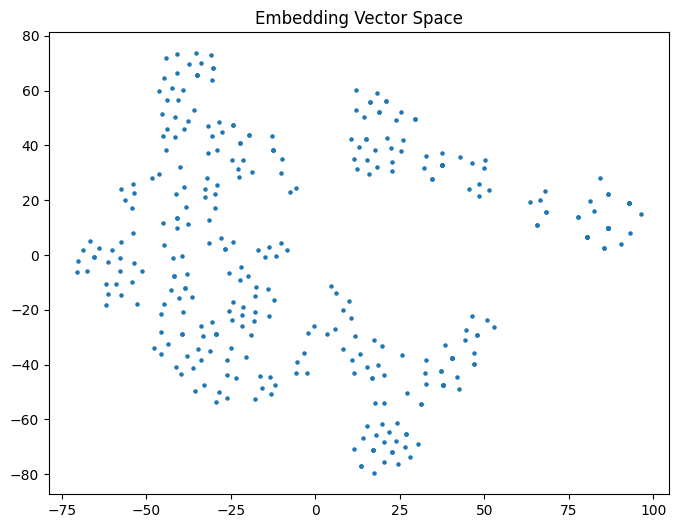

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

embeddings = np.load("results/iotid20_embeddings.npy")

tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], s=5)
plt.title("Embedding Vector Space")
plt.show()